In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from astropy.table import Table, vstack,hstack
import matplotlib

In [2]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [3]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v6.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90,BPT_class,sum_M_star_0p1_R90,count_M_star_0p1_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float

In [4]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/paper_plots/final/gaussian_fits/'

In [5]:
ellipticals = master_table[master_table['Mvir'] > 0]
ellipticals = ellipticals[ellipticals['sphd_M_star'] > 0]
spirals = master_table[master_table['v_max'] > 0]
spirals = spirals[spirals['M90_disk'] > 0]
spirals = spirals[spirals['alpha'] <= 99]
spirals = spirals[spirals['v_max_err']/spirals['v_max'] <= 2]
v90 = spirals['v_max'] * spirals['R90_kpc'] / (spirals['r_turn']**spirals['alpha'] + spirals['R90_kpc']**spirals['alpha'])**(1/spirals['alpha'])
all_mass_spirals = spirals[np.logical_and(v90 > 10, v90 < 1000)]
spirals = all_mass_spirals[all_mass_spirals['M90_disk']>9]

In [6]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [7]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [8]:
p3d = Table.read(DATA_FOLDER + 'SDSS17Pipe3D_v3_1_1.fits', format='fits')
p3d[:5]

name,plate,ifudsgn,plateifu,mangaid,objra,objdec,log_SFR_Ha,FoV,Re_kpc,e_log_Mass,e_log_SFR_Ha,log_Mass,log_SFR_ssp,log_NII_Ha_cen,e_log_NII_Ha_cen,log_OIII_Hb_cen,e_log_OIII_Hb_cen,log_SII_Ha_cen,e_log_SII_Ha_cen,log_OII_Hb_cen,e_log_OII_Hb_cen,EW_Ha_cen,e_EW_Ha_cen,ZH_LW_Re_fit,e_ZH_LW_Re_fit,alpha_ZH_LW_Re_fit,e_alpha_ZH_LW_Re_fit,ZH_MW_Re_fit,e_ZH_MW_Re_fit,alpha_ZH_MW_Re_fit,e_alpha_ZH_MW_Re_fit,Age_LW_Re_fit,e_Age_LW_Re_fit,alpha_Age_LW_Re_fit,e_alpha_Age_LW_Re_fit,Age_MW_Re_fit,e_Age_MW_Re_fit,alpha_Age_MW_Re_fit,e_alpha_Age_MW_Re_fit,Re_arc,DL,DA,PA,ellip,log_Mass_gas,vel_sigma_Re,e_vel_sigma_Re,log_SFR_SF,log_SFR_D_C,OH_O3N2_cen,e_OH_O3N2_cen,OH_N2_cen,e_OH_N2_cen,OH_ONS_cen,e_OH_ONS_cen,OH_R23_cen,e_OH_R23_cen,OH_pyqz_cen,e_OH_pyqz_cen,OH_t2_cen,e_OH_t2_cen,OH_M08_cen,e_OH_M08_cen,OH_T04_cen,e_OH_T04_cen,OH_dop_cen,e_OH_dop_cen,OH_O3N2_EPM09_cen,e_OH_O3N2_EPM09_cen,log_OI_Ha_cen,e_log_OI_Ha_cen,Ha_Hb_cen,e_Ha_Hb_cen,log_NII_Ha_Re,e_log_NII_Ha_Re,log_OIII_Hb_Re,e_log_OIII_Hb_Re,log_SII_Ha_Re,e_log_SII_Ha_Re,log_OII_Hb_Re,e_log_OII_Hb_Re,log_OI_Ha_Re,e_log_OI_Ha_Re,EW_Ha_Re,e_EW_Ha_Re,Ha_Hb_Re,e_Ha_Hb_Re,log_NII_Ha_ALL,e_log_NII_Ha_ALL,log_OIII_Hb_ALL,e_log_OIII_Hb_ALL,log_SII_Ha_ALL,e_log_SII_Ha_ALL,log_OII_Hb_ALL,e_log_OII_Hb_ALL,log_OI_Ha_ALL,e_log_OI_Ha_ALL,EW_Ha_ALL,e_EW_Ha_ALL,Ha_Hb_ALL,Sigma_Mass_cen,e_Sigma_Mass_cen,Sigma_Mass_Re,e_Sigma_Mass_Re,Sigma_Mass_ALL,e_Sigma_Mass_ALL,T30,ZH_T30,ZH_Re_T30,a_ZH_T30,T40,ZH_T40,ZH_Re_T40,a_ZH_T40,T50,ZH_T50,ZH_Re_T50,a_ZH_T50,T60,ZH_T60,ZH_Re_T60,a_ZH_T60,T70,ZH_T70,ZH_Re_T70,a_ZH_T70,T80,ZH_T80,ZH_Re_T80,a_ZH_T80,T90,ZH_T90,ZH_Re_T90,a_ZH_T90,T95,ZH_T95,ZH_Re_T95,a_ZH_T95,T99,ZH_T99,ZH_Re_T99,a_ZH_T99,log_Mass_gas_Av_gas_OH,log_Mass_gas_Av_ssp_OH,vel_ssp_2,e_vel_ssp_2,vel_Ha_2,e_vel_Ha_2,vel_ssp_1,e_vel_ssp_1,vel_Ha_1,e_vel_Ha_1,log_SFR_ssp_100Myr,log_SFR_ssp_10Myr,vel_disp_Ha_cen,vel_disp_ssp_cen,vel_disp_Ha_1Re,vel_disp_ssp_1Re,log_Mass_in_Re,ML_int,ML_avg,F_Ha_cen,e_F_Ha_cen,R50_kpc_V,e_R50_kpc_V,R50_kpc_Mass,e_R50_kpc_Mass,log_Mass_corr_in_R50_V,e_log_Mass_corr_in_R50_V,log_Mass_gas_Av_gas_log_log,Av_gas_Re,e_Av_gas_Re,Av_ssp_Re,e_Av_ssp_Re,Lambda_Re,e_Lambda_Re,nsa_redshift,nsa_mstar,nsa_inclination,flux_[OII]3726.03_Re_fit,e_flux_[OII]3726.03_Re_fit,flux_[OII]3726.03_alpha_fit,e_flux_[OII]3726.03_alpha_fit,flux_[OII]3728.82_Re_fit,e_flux_[OII]3728.82_Re_fit,flux_[OII]3728.82_alpha_fit,e_flux_[OII]3728.82_alpha_fit,flux_HI3734.37_Re_fit,e_flux_HI3734.37_Re_fit,flux_HI3734.37_alpha_fit,e_flux_HI3734.37_alpha_fit,flux_HI3797.9_Re_fit,e_flux_HI3797.9_Re_fit,flux_HI3797.9_alpha_fit,e_flux_HI3797.9_alpha_fit,flux_HeI3888.65_Re_fit,e_flux_HeI3888.65_Re_fit,flux_HeI3888.65_alpha_fit,e_flux_HeI3888.65_alpha_fit,flux_HI3889.05_Re_fit,e_flux_HI3889.05_Re_fit,flux_HI3889.05_alpha_fit,e_flux_HI3889.05_alpha_fit,flux_HeI3964.73_Re_fit,e_flux_HeI3964.73_Re_fit,flux_HeI3964.73_alpha_fit,e_flux_HeI3964.73_alpha_fit,flux_[NeIII]3967.46_Re_fit,e_flux_[NeIII]3967.46_Re_fit,flux_[NeIII]3967.46_alpha_fit,e_flux_[NeIII]3967.46_alpha_fit,flux_CaII3968.47_Re_fit,e_flux_CaII3968.47_Re_fit,flux_CaII3968.47_alpha_fit,e_flux_CaII3968.47_alpha_fit,flux_Hepsilon3970.07_Re_fit,e_flux_Hepsilon3970.07_Re_fit,flux_Hepsilon3970.07_alpha_fit,e_flux_Hepsilon3970.07_alpha_fit,flux_Hdelta4101.77_Re_fit,e_flux_Hdelta4101.77_Re_fit,flux_Hdelta4101.77_alpha_fit,e_flux_Hdelta4101.77_alpha_fit,flux_Hgamma4340.49_Re_fit,e_flux_Hgamma4340.49_Re_fit,flux_Hgamma4340.49_alpha_fit,e_flux_Hgamma4340.49_alpha_fit,flux_Hbeta4861.36_Re_fit,e_flux_Hbeta4861.36_Re_fit,flux_Hbeta4861.36_alpha_fit,e_flux_Hbeta4861.36_alpha_fit,flux_[OIII]4958.91_Re_fit,e_flux_[OIII]4958.91_Re_fit,flux_[OIII]4958.91_alpha_fit,e_flux_[OIII]4958.91_alpha_fit,flux_[OIII]5006.84_Re_fit,e_flux_[OIII]5006.84_Re_fit,flux_[OIII]5006.84_alpha_fit,e_flux_[OIII]5006.84_alpha_fit,flux_HeI5015.68_Re_fit,e_flux_HeI5015.68_Re_fit,flux_HeI5015.68_alpha_fit,e_flux_HeI5015.68_alpha_fit,flux_[NI]5197.9_Re_fit,e_flux_[NI]5197.9_Re_fit,flux_[NI]5197.9_alpha_fit

In [9]:
p3d_dict = {}
for i in range(len(p3d)):
    p3d_dict[p3d[i]['plateifu']] = i

In [10]:
ellipticals['Age_LW_Re_fit'] = -99.
ellipticals['Age_MW_Re_fit'] = -99.
ellipticals['ZH_LW_Re_fit'] = -99.
ellipticals['ZH_MW_Re_fit'] = -99.

for i in range(len(ellipticals)):

    try:

        i_p = p3d_dict[ellipticals[i]['plateifu']]

        ellipticals['Age_LW_Re_fit'][i] = p3d[i_p]['Age_LW_Re_fit']
        ellipticals['Age_MW_Re_fit'][i] = p3d[i_p]['Age_MW_Re_fit']
        ellipticals['ZH_LW_Re_fit'][i] = p3d[i_p]['ZH_LW_Re_fit']
        ellipticals['ZH_MW_Re_fit'][i] = p3d[i_p]['ZH_MW_Re_fit']
    
    except:
        print(ellipticals[i]['plateifu'])

10496-3704
10837-12702
11980-3703
12678-3702
12683-1902
9514-6102


/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value


In [11]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]
H_0 = 100 # [km / s / Mpc]
c = 299792.458 # Speed of light in units of km/s

In [12]:
blue_spirals = spirals[spirals['CMD_class'] == 1]
green_spirals = spirals[spirals['CMD_class']==2]
red_spirals = spirals[spirals['CMD_class']==3]

### minimize func

In [13]:
def gaussian(x, A, x0, sigma):

    return A * np.exp(-(x-x0)**2/(2*sigma**2))

def fit_to_gaussian(binned_data, plot_dir='', plot_name='', xlab=''):

    avgs = np.ones(len(binned_data)) * np.nan
    sigmas = np.ones(len(binned_data)) * np.nan

    for i in range(len(binned_data)):

        data = binned_data[i]
        
        counts, bins = np.histogram(data, bins=int(np.sqrt(len(data))+1))
        bin_ctrs = (bins[1:] + bins[:-1])/2

        p0 = [np.max(counts), bin_ctrs[np.argmax(counts)], 0.1]

        if len(data) >= 10:


            try:
    
                popt, pcov = curve_fit(gaussian, bin_ctrs, counts, p0=p0)
    
            except:
    
                print(f'failed on bin {i}')
                continue
    
            avgs[i] = popt[1]
            sigmas[i] = popt[2]
    
            plt.scatter(bin_ctrs, counts)
            xs = np.linspace(bins[0], bins[:-1], 100)
            plt.plot(xs, gaussian(xs, popt[0], popt[1], popt[2]), color='r', label=fr'$\mu$ = {popt[1]:.2}, $\sigma$ = {popt[2]:.2}')
            plt.xlabel(xlab)
    
            plt.title(plot_name + f'_bin_{i}')
            plt.savefig(plot_dir + plot_name + f'_bin_{i}' + '.png')
            plt.clf()

    return avgs, sigmas

### plots

In [14]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

e_mstar = []
b_s_mstar = []
g_s_mstar = []
r_s_mstar = []


for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['e_Mstar_R90'][ellipticals['rabsmag'] <= mag_lim]+np.log10(0.73))
        r_s_mstar.append(red_spirals['M90_disk'][red_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))
        b_s_mstar.append(blue_spirals['M90_disk'][blue_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))
        g_s_mstar.append(green_spirals['M90_disk'][green_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))

    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['e_Mstar_R90'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]+np.log10(0.73))
        
        r_s_mstar.append(red_spirals['M90_disk'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))
        b_s_mstar.append(blue_spirals['M90_disk'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))
        g_s_mstar.append(green_spirals['M90_disk'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))


In [15]:
counts, bins = np.histogram(e_mstar[4], bins=30)

In [16]:
counts

array([ 1,  0,  1,  0,  1,  3,  4,  1,  7,  6,  9, 15, 17, 10, 25, 28, 21,
       19, 14,  9,  7, 12,  2,  2,  2,  1,  0,  0,  0,  1])

In [20]:
bins

array([10.52950576, 10.55427491, 10.57904406, 10.60381321, 10.62858236,
       10.65335151, 10.67812066, 10.70288981, 10.72765896, 10.7524281 ,
       10.77719725, 10.8019664 , 10.82673555, 10.8515047 , 10.87627385,
       10.901043  , 10.92581215, 10.9505813 , 10.97535045, 11.0001196 ,
       11.02488875, 11.0496579 , 11.07442705, 11.0991962 , 11.12396535,
       11.1487345 , 11.17350365, 11.1982728 , 11.22304195, 11.2478111 ,
       11.27258025])

In [21]:
idxs = np.digitize(e_mstar[4], bins)

In [24]:
np.max(idxs)

31

In [33]:
bin_ctr = (bins[1:] + bins[:-1])/2
for i in range(1,len(bins)):
    pts = e_mstar[4][idx==i]
    
    bin_ctr[i-1] = np.mean(e_mstar[4][idxs==i])

In [27]:
bin_ctr = (bins[1:] + bins[:-1]) / 2
bin_ctr

array([10.54189033, 10.56665948, 10.59142863, 10.61619778, 10.64096693,
       10.66573608, 10.69050523, 10.71527438, 10.74004353, 10.76481268,
       10.78958183, 10.81435098, 10.83912013, 10.86388928, 10.88865843,
       10.91342758, 10.93819673, 10.96296588, 10.98773503, 11.01250417,
       11.03727332, 11.06204247, 11.08681162, 11.11158077, 11.13634992,
       11.16111907, 11.18588822, 11.21065737, 11.23542652, 11.26019567])

In [28]:
popt, pcov = curve_fit(gaussian, bin_ctr, counts, p0=[25, 10.9, 0.1])

In [29]:
popt

array([22.06747698, 10.91013598,  0.09409838])

In [35]:
bin_ctr

array([10.52950576,         nan, 10.60214203,         nan, 10.64734026,
       10.66188999, 10.69010896, 10.71720571, 10.73914006, 10.76705349,
       10.79089017, 10.81442529, 10.83771571, 10.86096968, 10.8867622 ,
       10.91333514, 10.93695546, 10.96375126, 10.99100556, 11.00944479,
       11.03621257, 11.05750819, 11.09870942, 11.11017907, 11.14306201,
       11.15713952,         nan,         nan,         nan,         nan])

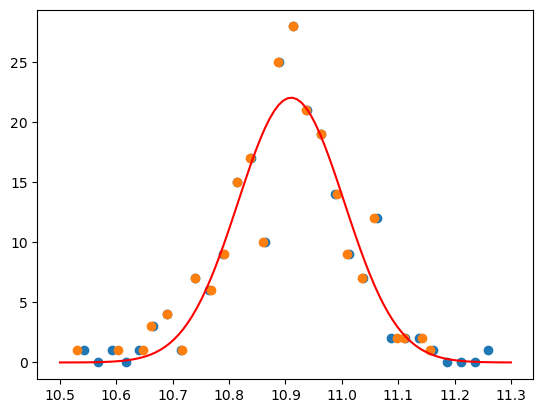

In [34]:
plt.scatter((bins[1:] + bins[:-1])/2, counts)
plt.plot(np.linspace(10.5,11.3, 100), gaussian(np.linspace(10.5,11.3, 100), popt[0], popt[1], popt[2]), color='r')
plt.scatter(bin_ctr, counts)

In [69]:
len(e_mstar[0])

167

In [70]:
r_s_mstar

[<MaskedColumn name='M90_disk' dtype='float64' length=0>,
 <MaskedColumn name='M90_disk' dtype='float64' length=10>
  11.39499271560743
 11.327304376989026
 11.304768872823423
 11.184050342443808
  11.43931427976969
 11.192803173926887
 11.456593813005053
 11.275142089521538
 11.371083802358154
  11.28524676174387,
 <MaskedColumn name='M90_disk' dtype='float64' length=24>
 11.140495245511723
 11.173353464783585
 11.038861246158746
 11.321211976928463
 11.098048637614134
 11.100371500273472
 11.111535140656187
 11.273503661406757
 11.251919599066607
 11.056910411609078
  11.12684839625214
  11.02053027755975
 11.230946665797095
 11.126916405609617
 11.049966128319944
 11.358224410906281
 11.105640829660551
 11.223135581757042
   11.0559921925041
 11.336401856986171
  11.27207726604382
  11.22562204303518
 11.007162724308145
 11.338053183218129,
 <MaskedColumn name='M90_disk' dtype='float64' length=59>
 11.090825532673737
 11.101919950493453
 11.297516123281444
 10.869704755534308
 11.13

In [73]:
fit_to_gaussian?

Signature: fit_to_gaussian(binned_data, plot_dir='', plot_name='', xlab='')
Docstring: <no docstring>
File:      /var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_98305/2748718686.py
Type:      function

In [138]:
avg, sig = fit_to_gaussian(e_mstar, plot_dir = plot_dir + 'test/', plot_name='ellipticals_Mr', xlab=r'$M_*$')

<Figure size 640x480 with 0 Axes>

In [110]:
avg

array([11.61595936, 11.44178267, 11.28384067, 11.08894169, 10.91010166,
       10.71891026, 10.50483859, 10.32912983, 10.12116587,  9.84784986,
        9.64590358,  9.4886708 ,         nan,  9.23689331])

In [115]:
np.mean(e_mstar[0])

11.614893217760258

(array([ 1.,  0.,  5., 19., 38., 37., 40., 19.,  5.,  3.]),
 array([11.24415391, 11.3113272 , 11.3785005 , 11.44567379, 11.51284709,
        11.58002038, 11.64719368, 11.71436697, 11.78154027, 11.84871356,
        11.91588686]),
 <BarContainer object of 10 artists>)

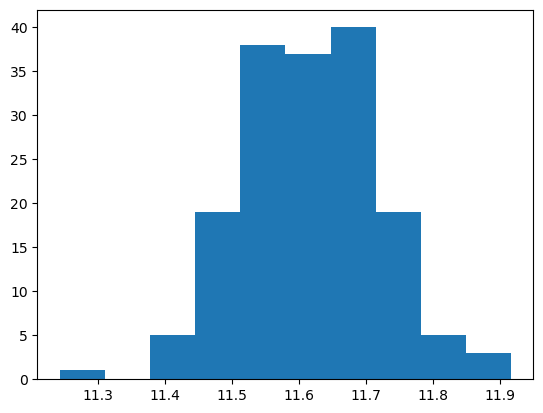

In [117]:
plt.hist(e_mstar[0])

<ErrorbarContainer object of 3 artists>

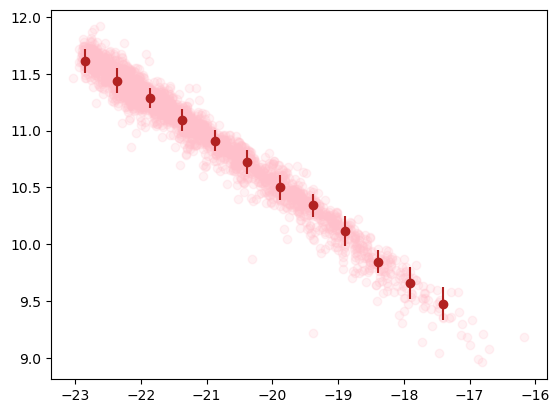

In [139]:
plt.scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90']+np.log10(0.73), color='pink', alpha=0.2, marker='o')
plt.errorbar(pts, avg, yerr=sig, linestyle='none', marker='o', color='firebrick')

(array([1., 1., 8., 8.]),
 array([9.0428056 , 9.18579848, 9.32879135, 9.47178422, 9.61477709]),
 <BarContainer object of 4 artists>)

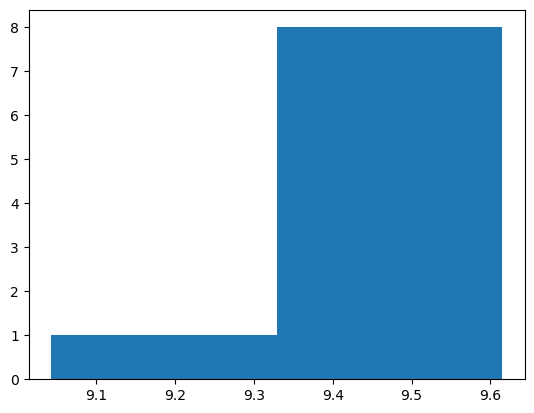

In [133]:
plt.hist(e_mstar[11], bins=4)

In [132]:
np.sqrt(18)

4.242640687119285